# Compare Three Runs (No Widgets)

**Instructions:**
1. Run the "Load data" cell once.
2. Edit the values in the "Set parameters" cell.
3. Run the "Plot comparison" cell to see the result.
4. To change parameters, edit the values in the "Set parameters" cell and run that cell again (or simply re‑run the "Plot comparison" cell after editing).

In [4]:
# ═══════════════════════════════════════════════════════════
# 1. Load data
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Find all_results.csv
candidates = [
    'all_results.csv',
    os.path.join('..', 'all_results.csv'),
]
csv_path = None
for p in candidates:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("all_results.csv not found. Place it next to this notebook or one level up.")

df = pd.read_csv(csv_path)
df['algorithm'] = df['pca'].map({True: 'PCA-DEA', False: 'UMAP-DEA'})

print(f"Loaded {len(df)} rows from {csv_path}")
print("Available parameter values:")
print(f"  Algorithm: {sorted(df['algorithm'].unique())}")
print(f"  N:         {sorted(df['N'].unique())}")
print(f"  n:         {sorted(df['n'].unique())}")
print(f"  RTS:       {sorted(df['rts'].unique())}")
print(f"  Gamma:     {sorted(df['gamma'].unique())}")
print(f"  Metrics:   MAE, Spearman, Pearson, Kendall, Proportion Efficient, Number Efficient")
print(f"  umap_n_neighbors & nr_simulations depend on your (algo, N, n) choices —")
print(f"  run the Plot cell to see valid options for your parameters")

Loaded 295 rows from ../all_results.csv
Available parameter values:
  Algorithm: ['PCA-DEA', 'UMAP-DEA']
  N:         [10, 20, 50, 100]
  n:         [10, 20, 25, 40, 50, 80, 100, 125, 200, 250, 400, 500, 1000]
  RTS:       ['vrs']
  Gamma:     [0.5]
  Metrics:   MAE, Spearman, Pearson, Kendall, Proportion Efficient, Number Efficient
  umap_n_neighbors & nr_simulations depend on your (algo, N, n) choices —
  run the Plot cell to see valid options for your parameters


In [5]:
# ═══════════════════════════════════════════════════════════
# 2. Set parameters (edit these values)
# ═══════════════════════════════════════════════════════════

# ── Run A ──
RUN_A_ALGO              = 'PCA-DEA'   # 'UMAP-DEA' or 'PCA-DEA'
RUN_A_N                 = 50           # from printed N values
RUN_A_n                 = 200          # from printed n values
RUN_A_RTS               = 'vrs'        # 'vrs' or 'crs'
RUN_A_GAMMA             = 0.5          # from printed gamma values
RUN_A_UMAP_N_NEIGHBORS  = 3            # UMAP n_neighbors (used for filtering, even for PCA-DEA)
RUN_A_NR_SIMULATIONS    = 100          # nr_simulations

# ── Run B ──
RUN_B_ALGO              = 'UMAP-DEA'
RUN_B_N                 = 50
RUN_B_n                 = 200
RUN_B_RTS               = 'vrs'
RUN_B_GAMMA             = 0.5
RUN_B_UMAP_N_NEIGHBORS  = 14           # UMAP n_neighbors (used for filtering, even for PCA-DEA)
RUN_B_NR_SIMULATIONS    = 100          # nr_simulations

# ── Run C ──
RUN_C_ALGO              = 'UMAP-DEA'
RUN_C_N                 = 50
RUN_C_n                 = 200
RUN_C_RTS               = 'vrs'
RUN_C_GAMMA             = 0.5
RUN_C_UMAP_N_NEIGHBORS  = 100            # UMAP n_neighbors (used for filtering, even for PCA-DEA)
RUN_C_NR_SIMULATIONS    = 100          # nr_simulations

# ── Shared ──
METRIC_NAME = 'Kendall'    # any from the list above
SHOW_STD    = True         # True or False

──────────────────────────────────────────────────
  Valid umap_n_neighbors for Run A (PCA-DEA, N=50, n=200, vrs, γ=0.5): [3]
  Valid nr_simulations    for Run A (PCA-DEA, N=50, n=200, vrs, γ=0.5): [100]
  Valid umap_n_neighbors for Run B (UMAP-DEA, N=50, n=200, vrs, γ=0.5): [7, 14, 100]
  Valid nr_simulations    for Run B (UMAP-DEA, N=50, n=200, vrs, γ=0.5): [100]
  Valid umap_n_neighbors for Run C (UMAP-DEA, N=50, n=200, vrs, γ=0.5): [7, 14, 100]
  Valid nr_simulations    for Run C (UMAP-DEA, N=50, n=200, vrs, γ=0.5): [100]
──────────────────────────────────────────────────


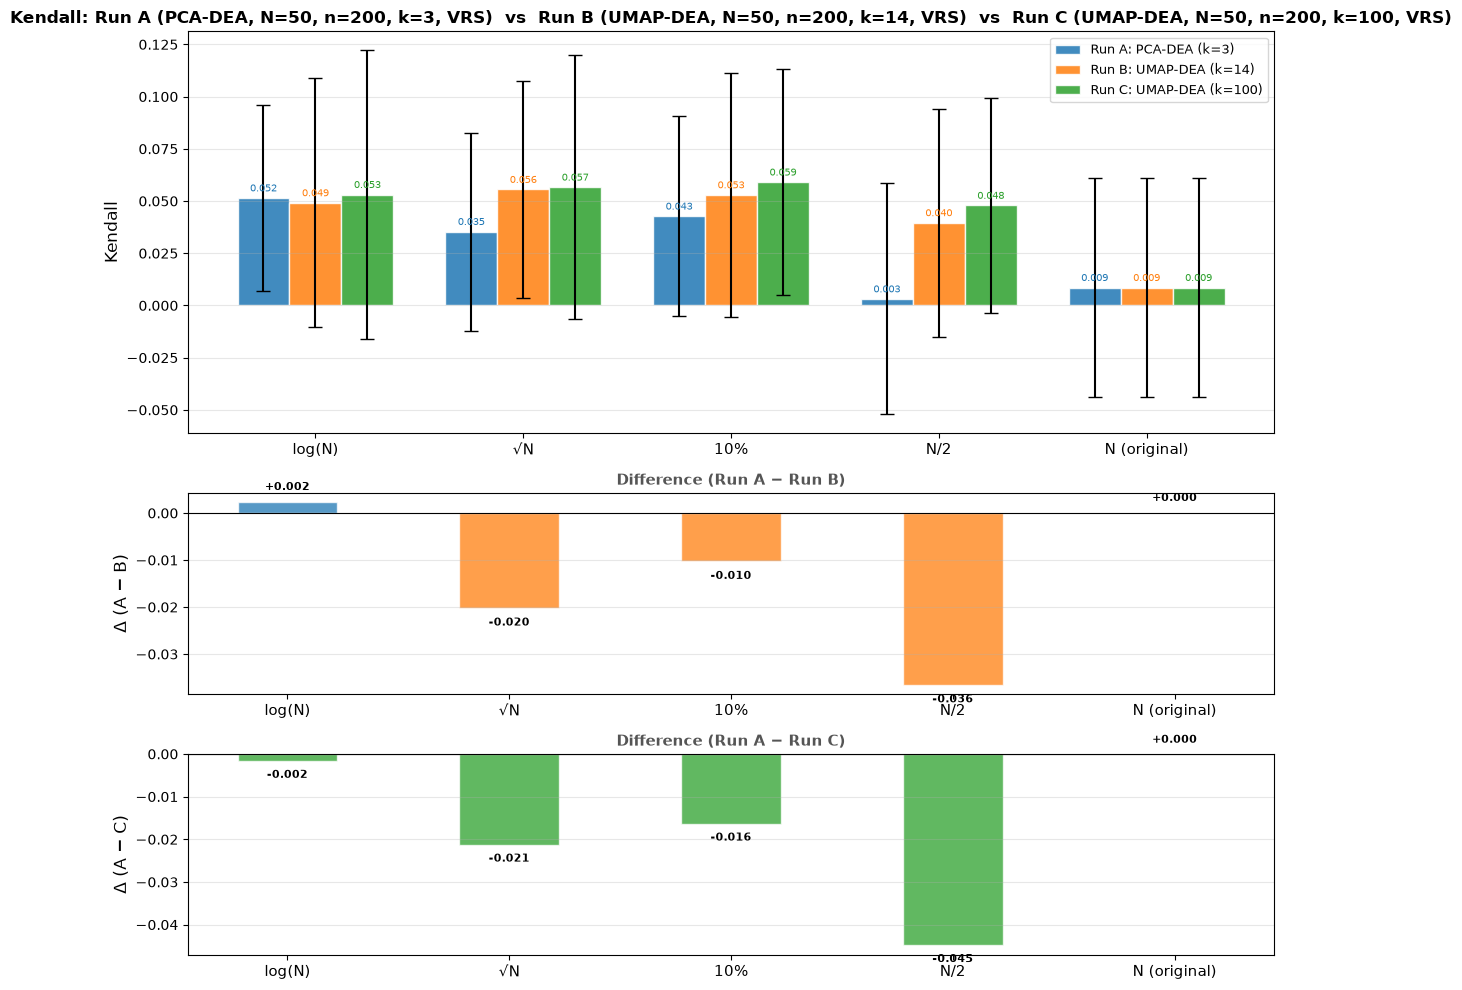


Comparison Table — Kendall   (Run A: ns=100, seeds=1   Run B: ns=100, seeds=1   Run C: ns=100, seeds=1)


,Dim Reduction,Run A (Kendall),Run B (Kendall),Run C (Kendall),Δ (A−B),Δ (A−C)
0,log(N),0.05150,0.04918,0.05312,+0.00233,-0.00162
1,√N,0.03542,0.05555,0.05665,-0.02014,-0.02124
2,10%,0.04277,0.05298,0.05908,-0.01021,-0.01631
3,N/2,0.00315,0.03962,0.04792,-0.03647,-0.04477
4,N (original),0.00860,0.00860,0.00860,+0.00000,+0.00000


In [6]:
# ═══════════════════════════════════════════════════════════
# 3. Plot comparison (just run this cell after setting parameters)
# ═══════════════════════════════════════════════════════════

# Metric mapping
METRICS = {
    'MAE':                  ('mae_mean', 'mae_std'),
    'Spearman':             ('spearmanr_mean', 'spearmanr_std'),
    'Pearson':              ('pearsonr_mean', 'pearsonr_std'),
    'Kendall':              ('kendalltau_mean', 'kendalltau_std'),
    'Proportion Efficient': ('prop_efficient_mean', 'prop_efficient_std'),
    'Number Efficient':     ('nr_efficient_mean', 'nr_efficient_std'),
}
mean_col, std_col = METRICS[METRIC_NAME]

# Dimension order
DIM_ORDER = ['log', 'sqrt', 'ten_percent', 'half', 'original']
DIM_LABELS = ['log(N)', '√N', '10%', 'N/2', 'N (original)']
COLOR_A = '#1f77b4'
COLOR_B = '#ff7f0e'
COLOR_C = '#2ca02c'

# ── Helper: show valid sub-parameters for a given base filter ──
def show_valid_options(label, df_sub):
    if len(df_sub) == 0:
        print(f'  {label} → No matching data for these base parameters!')
        return
    valid_k  = sorted(df_sub['umap_n_neighbors'].unique())
    valid_nr = sorted(df_sub['nr_simulations'].unique())
    print(f'  Valid umap_n_neighbors for {label}: {valid_k}')
    print(f'  Valid nr_simulations    for {label}: {valid_nr}')

# Partial filter (base params only) to show valid choices
mask_a_base = (
    (df['algorithm'] == RUN_A_ALGO) &
    (df['N'] == RUN_A_N) &
    (df['n'] == RUN_A_n) &
    (df['rts'] == RUN_A_RTS) &
    (df['gamma'] == RUN_A_GAMMA)
)
mask_b_base = (
    (df['algorithm'] == RUN_B_ALGO) &
    (df['N'] == RUN_B_N) &
    (df['n'] == RUN_B_n) &
    (df['rts'] == RUN_B_RTS) &
    (df['gamma'] == RUN_B_GAMMA)
)
mask_c_base = (
    (df['algorithm'] == RUN_C_ALGO) &
    (df['N'] == RUN_C_N) &
    (df['n'] == RUN_C_n) &
    (df['rts'] == RUN_C_RTS) &
    (df['gamma'] == RUN_C_GAMMA)
)

print('─' * 50)
show_valid_options(f'Run A ({RUN_A_ALGO}, N={RUN_A_N}, n={RUN_A_n}, {RUN_A_RTS}, γ={RUN_A_GAMMA})', df[mask_a_base])
show_valid_options(f'Run B ({RUN_B_ALGO}, N={RUN_B_N}, n={RUN_B_n}, {RUN_B_RTS}, γ={RUN_B_GAMMA})', df[mask_b_base])
show_valid_options(f'Run C ({RUN_C_ALGO}, N={RUN_C_N}, n={RUN_C_n}, {RUN_C_RTS}, γ={RUN_C_GAMMA})', df[mask_c_base])
print('─' * 50)

# Check that the user's sub-parameter choices exist
mask_a_check = mask_a_base & (df['umap_n_neighbors'] == RUN_A_UMAP_N_NEIGHBORS) & (df['nr_simulations'] == RUN_A_NR_SIMULATIONS)
mask_b_check = mask_b_base & (df['umap_n_neighbors'] == RUN_B_UMAP_N_NEIGHBORS) & (df['nr_simulations'] == RUN_B_NR_SIMULATIONS)
mask_c_check = mask_c_base & (df['umap_n_neighbors'] == RUN_C_UMAP_N_NEIGHBORS) & (df['nr_simulations'] == RUN_C_NR_SIMULATIONS)

invalid = False
if mask_a_check.sum() == 0:
    valid_k  = sorted(df[mask_a_base]['umap_n_neighbors'].unique())
    valid_nr = sorted(df[mask_a_base]['nr_simulations'].unique())
    print(f'❌ No data for Run A with umap_n_neighbors={RUN_A_UMAP_N_NEIGHBORS}, nr_simulations={RUN_A_NR_SIMULATIONS}')
    print(f'   Valid umap_n_neighbors: {valid_k}')
    print(f'   Valid nr_simulations:    {valid_nr}')
    invalid = True
if mask_b_check.sum() == 0:
    valid_k  = sorted(df[mask_b_base]['umap_n_neighbors'].unique())
    valid_nr = sorted(df[mask_b_base]['nr_simulations'].unique())
    print(f'❌ No data for Run B with umap_n_neighbors={RUN_B_UMAP_N_NEIGHBORS}, nr_simulations={RUN_B_NR_SIMULATIONS}')
    print(f'   Valid umap_n_neighbors: {valid_k}')
    print(f'   Valid nr_simulations:    {valid_nr}')
    invalid = True
if mask_c_check.sum() == 0:
    valid_k  = sorted(df[mask_c_base]['umap_n_neighbors'].unique())
    valid_nr = sorted(df[mask_c_base]['nr_simulations'].unique())
    print(f'❌ No data for Run C with umap_n_neighbors={RUN_C_UMAP_N_NEIGHBORS}, nr_simulations={RUN_C_NR_SIMULATIONS}')
    print(f'   Valid umap_n_neighbors: {valid_k}')
    print(f'   Valid nr_simulations:    {valid_nr}')
    invalid = True
if invalid:
    raise SystemExit

# Full filter data
mask_a = mask_a_check
mask_b = mask_b_check
mask_c = mask_c_check

df_a = df[mask_a].copy()
df_b = df[mask_b].copy()
df_c = df[mask_c].copy()

# Align levels across all three runs
levels_present = (
    set(df_a['dim_reduction_level'].unique())
    & set(df_b['dim_reduction_level'].unique())
    & set(df_c['dim_reduction_level'].unique())
)
levels_ordered = [l for l in DIM_ORDER if l in levels_present]
labels_ordered = [DIM_LABELS[DIM_ORDER.index(l)] for l in levels_ordered]

if len(levels_ordered) == 0:
    print('⚠️ No common dim_reduction_level values between the three runs.')
    raise SystemExit

# Aggregate (mean over seeds)
agg_a = df_a.groupby('dim_reduction_level').agg(
    metric_mean=(mean_col, 'mean'),
    metric_std=(std_col, 'mean'),
    n_seeds=('seed', 'nunique'),
).reindex(levels_ordered).reset_index()

agg_b = df_b.groupby('dim_reduction_level').agg(
    metric_mean=(mean_col, 'mean'),
    metric_std=(std_col, 'mean'),
    n_seeds=('seed', 'nunique'),
).reindex(levels_ordered).reset_index()

agg_c = df_c.groupby('dim_reduction_level').agg(
    metric_mean=(mean_col, 'mean'),
    metric_std=(std_col, 'mean'),
    n_seeds=('seed', 'nunique'),
).reindex(levels_ordered).reset_index()

# Plot
fig, (ax_bar, ax_diff_ab, ax_diff_ac) = plt.subplots(3, 1, figsize=(12, 10),
    gridspec_kw={'height_ratios': [3, 1.5, 1.5]})
x = np.arange(len(levels_ordered))
width = 0.25

# Bars
yerr_a = agg_a['metric_std'].values if SHOW_STD else None
bars_a = ax_bar.bar(x - width, agg_a['metric_mean'].values, width,
                    yerr=yerr_a, capsize=5, color=COLOR_A, alpha=0.85, edgecolor='white',
                    label=f'Run A: {RUN_A_ALGO} (k={RUN_A_UMAP_N_NEIGHBORS})')
yerr_b = agg_b['metric_std'].values if SHOW_STD else None
bars_b = ax_bar.bar(x, agg_b['metric_mean'].values, width,
                    yerr=yerr_b, capsize=5, color=COLOR_B, alpha=0.85, edgecolor='white',
                    label=f'Run B: {RUN_B_ALGO} (k={RUN_B_UMAP_N_NEIGHBORS})')
yerr_c = agg_c['metric_std'].values if SHOW_STD else None
bars_c = ax_bar.bar(x + width, agg_c['metric_mean'].values, width,
                    yerr=yerr_c, capsize=5, color=COLOR_C, alpha=0.85, edgecolor='white',
                    label=f'Run C: {RUN_C_ALGO} (k={RUN_C_UMAP_N_NEIGHBORS})')

# Annotate bars
for bar, color in [(bars_a, COLOR_A), (bars_b, COLOR_B), (bars_c, COLOR_C)]:
    for rect in bar:
        h = rect.get_height()
        if not np.isnan(h):
            ax_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002,
                        f'{h:.3f}', ha='center', va='bottom', fontsize=7, color=color)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(labels_ordered, fontsize=11)
ax_bar.set_ylabel(METRIC_NAME, fontsize=12)
ax_bar.set_title(
    f'{METRIC_NAME}: '
    f'Run A ({RUN_A_ALGO}, N={RUN_A_N}, n={RUN_A_n}, k={RUN_A_UMAP_N_NEIGHBORS}, {RUN_A_RTS.upper()})  vs  '
    f'Run B ({RUN_B_ALGO}, N={RUN_B_N}, n={RUN_B_n}, k={RUN_B_UMAP_N_NEIGHBORS}, {RUN_B_RTS.upper()})  vs  '
    f'Run C ({RUN_C_ALGO}, N={RUN_C_N}, n={RUN_C_n}, k={RUN_C_UMAP_N_NEIGHBORS}, {RUN_C_RTS.upper()})',
    fontsize=12, fontweight='bold'
)
ax_bar.legend(fontsize=9, loc='best')
ax_bar.grid(True, alpha=0.3, axis='y')

# Difference panel: Δ (A − B)
diff_ab = agg_a['metric_mean'].values - agg_b['metric_mean'].values
diff_ab_colors = [COLOR_A if d >= 0 else COLOR_B for d in diff_ab]
ax_diff_ab.bar(x, diff_ab, width * 1.8, color=diff_ab_colors, alpha=0.75, edgecolor='white')
ax_diff_ab.axhline(y=0, color='black', linewidth=0.8)
for i, d in enumerate(diff_ab):
    if not np.isnan(d):
        va = 'bottom' if d >= 0 else 'top'
        offset = 0.002 if d >= 0 else -0.002
        ax_diff_ab.text(i, d + offset, f'{d:+.3f}', ha='center', va=va, fontsize=8,
                        color='black', fontweight='bold')
ax_diff_ab.set_xticks(x)
ax_diff_ab.set_xticklabels(labels_ordered, fontsize=11)
ax_diff_ab.set_ylabel('Δ (A − B)', fontsize=12)
ax_diff_ab.set_title('Difference (Run A − Run B)', fontsize=11, fontweight='bold', color='#555555')
ax_diff_ab.grid(True, alpha=0.3, axis='y')

# Difference panel: Δ (A − C)
diff_ac = agg_a['metric_mean'].values - agg_c['metric_mean'].values
diff_ac_colors = [COLOR_A if d >= 0 else COLOR_C for d in diff_ac]
ax_diff_ac.bar(x, diff_ac, width * 1.8, color=diff_ac_colors, alpha=0.75, edgecolor='white')
ax_diff_ac.axhline(y=0, color='black', linewidth=0.8)
for i, d in enumerate(diff_ac):
    if not np.isnan(d):
        va = 'bottom' if d >= 0 else 'top'
        offset = 0.002 if d >= 0 else -0.002
        ax_diff_ac.text(i, d + offset, f'{d:+.3f}', ha='center', va=va, fontsize=8,
                        color='black', fontweight='bold')
ax_diff_ac.set_xticks(x)
ax_diff_ac.set_xticklabels(labels_ordered, fontsize=11)
ax_diff_ac.set_ylabel('Δ (A − C)', fontsize=12)
ax_diff_ac.set_title('Difference (Run A − Run C)', fontsize=11, fontweight='bold', color='#555555')
ax_diff_ac.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
table_data = {
    'Dim Reduction': labels_ordered,
    f'Run A ({METRIC_NAME})': [f'{v:.5f}' if not np.isnan(v) else 'NaN' for v in agg_a['metric_mean'].values],
    f'Run B ({METRIC_NAME})': [f'{v:.5f}' if not np.isnan(v) else 'NaN' for v in agg_b['metric_mean'].values],
    f'Run C ({METRIC_NAME})': [f'{v:.5f}' if not np.isnan(v) else 'NaN' for v in agg_c['metric_mean'].values],
    'Δ (A−B)': [f'{d:+.5f}' if not np.isnan(d) else 'NaN' for d in diff_ab],
    'Δ (A−C)': [f'{d:+.5f}' if not np.isnan(d) else 'NaN' for d in diff_ac],
}
table_df = pd.DataFrame(table_data)
caption = (f"Comparison Table — {METRIC_NAME}   "
           f"(Run A: ns={RUN_A_NR_SIMULATIONS}, seeds={int(agg_a['n_seeds'].iloc[0])}   "
           f"Run B: ns={RUN_B_NR_SIMULATIONS}, seeds={int(agg_b['n_seeds'].iloc[0])}   "
           f"Run C: ns={RUN_C_NR_SIMULATIONS}, seeds={int(agg_c['n_seeds'].iloc[0])})")
print(f'\n{caption}')
print('=' * len(caption))
display(table_df)